# FLAMS: example use cases 

This notebook contains the Supplementary material (use cases) to 'Finding Lysine Acylations and other Modification Sites'. 

To run the last example, it requires the following files in the working directory: 
 - suppl_muroski2022_acetylation.txt 
 - suppl_muroski2022_glutarylation.txt
 - suppl_muroski2022_benzoylation.txt
 - suppl_muroski2022_crotonylation.txt 
 - suppl_muroski2022_butyrylation.txt 
 - suppl_muroski2022_oxidation.txt 

## Before using: installing FLAMS

This notebook was created in a fresh conda environment (with Python 3.10), in which only jupyter notebooks had been installed by running:

    conda install -c conda-forge notebook=6.5.2
    conda install -c conda-forge nb_conda_kernels

### Installing FLAMS with pip

In [1]:
pip install flams

  Using cached charset_normalizer-3.3.2-cp310-cp310-win_amd64.whl.metadata (34 kB)
  Using cached pandas-2.1.2-cp310-cp310-win_amd64.whl.metadata (18 kB)
  Using cached pytz-2023.3.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached requests-2.29.0-py3-none-any.whl (62 kB)
  Using cached tzdata-2023.3-py2.py3-none-any.whl (341 kB)
  Using cached urllib3-1.26.18-py2.py3-none-any.whl.metadata (48 kB)
Using cached charset_normalizer-3.3.2-cp310-cp310-win_amd64.whl (100 kB)
Using cached pandas-2.1.2-cp310-cp310-win_amd64.whl (10.7 MB)
Using cached pytz-2023.3.post1-py2.py3-none-any.whl (502 kB)
Using cached urllib3-1.26.18-py2.py3-none-any.whl (143 kB)
Note: you may need to restart the kernel to use updated packages.


## Example use cases

### TatA acetylation - verifying whether a modification has been reported before

In [2021, Greiner-Haas *et al.*](https://doi.org/10.3390/microorganisms9020365) described the proteome and acetylome of *Dehalococcoides mccartyi* strain CBDB1. Among the identified acetylation sites, they describe TatA (a component of the twin-arginine translocation machinery) as highly acetylated, exclusively in the stationary phase. They discuss that to their knowledge, no acetylation of Tat components has so far been reported in the literature. 

Using FLAMS, we assessed whether acetylation of TatA, at the exact site they report (K66), had been described before. We retrieved the TatA UniProt ID by matching the reported UniProt ID Q3ZW48 (Supplementary table S2-B) to its currently active UniProt ID A0A916NWA0 by making use of UniParc.

In [2]:
!FLAMS --id A0A916NWA0 -p 66 -m acetylation -o tatA.tsv
!cat tatA.tsv



Building a new DB, current time: 12/04/2023 16:00:23
New DB name:   C:\Users\hanne\AppData\Local\flams\flams\acetylation-1.1
New DB title:  acetylation-1.1.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 344088 sequences in 19.9404 seconds.




[04/12 16:00:05] INFO: The set of amino acids capable of carrying all your specified modifications ['acetylation'] was determined as {'D', 'G', 'C', 'M', 'P', 'R', 'S', 'T', 'E', 'A', 'V', 'Y', 'K'}.
[04/12 16:00:05] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:00:06] INFO: Downloading FLAMS acetylation Database 1.1, please wait. Size: 60.2 MB
[04/12 16:00:45] INFO: Data directory created: C:\Users\hanne\Bureaublad\supplementary\data
[04/12 16:00:45] INFO: Retrieving FASTA file for Uniprot ID A0A916NWA0 at https://rest.uniprot.org/uniprotkb/A0A916NWA0.fasta
[04/12 16:00:46] INFO: Stored FASTA file for UniProt ID A0A916NWA0 at C:\Users\hanne\Bureaublad\supplementary\data\A0A916NWA0.fasta.tmp
[04/12 16:00:46] INFO: Based on your provided information, we are screening for the following modifications: ['acetylation'] (on amino acid K).
[04/12 16:00:46] INFO: Running BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\A0A916NWA0.fasta.tmp against lo

Uniprot ID	Protein name	Modification	K location	K window	Species	BLAST E-value	BLAST identity	BLAST coverage	CPLM ID	CPLM evidence code	CPLM evidence links	dbPTM evidence code	dbPTM evidence links
P69428	tatA	Acetylation	62	57-ADFTAKTIADK-67	Escherichia coli (strain K12)	0.000431986	32.05%	98.72%	CPLM017774	Exp.	23830618	Exp.	23830618


**With FLAMS, it was easy to detect that this acetylation site had already been reported in *Escherichia coli* strain K12's TatA**, in a [2013 study by Weinert *et al.*](https://doi.org/10.1016/j.celrep.2013.07.024). We got this link from the PubMed ID reported both in dbPTM and CPLM. While this protein is also TatA, we can see from the BLAST statistics that the % identity is relatively low. 

### FadD enzymes - investigating whether functional insights might extrapolate to other species

In [2020, Xu *et al.*](https://doi.org/10.1128/mSystems.00424-19) studied the *Mycobacterium smegmatis* proteome and its post-translational modifications, to improve the understanding of *Mycobacterium* cholesterol catabolism. Given the high conservation of the cholesterol catabolism pathway among *Mycobacteria*, improved understanding of its regulation could inspire new anti-tuberculosis drugs. Among their results, Xu describes 3 essential adenylating enzymes (FadD2, FadD4 and FadD35), that were inhibited by lysine propionylation. They discuss how their inhibition could lead to an imbalance of acyl-CoA, which could be detrimental for the bacterial cell. Hence, this regulatory mechanism might inspire new anti-tuberculosis drug design.

With FLAMS, we checked whether the modifications reported in FadD2, FadD4 and FadD35 were previously found in *Mycobacterium tuberculosis*. 

In [3]:
!FLAMS --id A0QQ22 -p 537 -m CPLM-Acylations -o FadD2.tsv
!cat FadD2.tsv | grep 'Mycobacterium tuberculosis'



Building a new DB, current time: 12/04/2023 16:01:27
New DB name:   C:\Users\hanne\AppData\Local\flams\flams\lactylation-1.1
New DB title:  lactylation-1.1.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 700 sequences in 0.0284053 seconds.




Building a new DB, current time: 12/04/2023 16:01:31
New DB name:   C:\Users\hanne\AppData\Local\flams\flams\succinylation-1.1
New DB title:  succinylation-1.1.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 47225 sequences in 2.52791 seconds.




Building a new DB, current time: 12/04/2023 16:01:35
New DB name:   C:\Users\hanne\AppData\Local\flams\flams\crotonylation-1.1
New DB title:  crotonylation-1.1.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 20155 sequences in 0.777909 seconds.




Building a new DB, current time: 12/04/2023 16:01:39
New DB name:   C:\Use

[04/12 16:01:26] INFO: The set of amino acids capable of carrying all your specified modifications ['succinylation', 'formylation', 'butyrylation', 'mgylation', 'crotonylation', 'hmgylation', 'acetylation', 'benzoylation', 'malonylation', 'lactylation', 'propionylation', 'beta-hydroxybutyrylation', 'mgcylation', '2-hydroxyisobutyrylation', 'glutarylation'] was determined as {'K'}.
[04/12 16:01:26] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:01:27] INFO: Downloading FLAMS lactylation Database 1.1, please wait. Size: 0.1 MB
[04/12 16:01:29] INFO: Downloading FLAMS succinylation Database 1.1, please wait. Size: 5.2 MB
[04/12 16:01:35] INFO: Downloading FLAMS crotonylation Database 1.1, please wait. Size: 2.1 MB
[04/12 16:01:38] INFO: Downloading FLAMS malonylation Database 1.1, please wait. Size: 3.5 MB
[04/12 16:01:42] INFO: Downloading FLAMS beta-hydroxybutyrylation Database 1.1, please wait. Size: 0.7 MB
[04/12 16:01:44] INFO: Downloading FLAMS benzoyla

O06417	fadD8	Succinylation	552	547-LTGLGKPDKKA-557	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	7.85086e-38	30.72%	53.65%	CPLM000329	Exp.	25363132;25605462	Exp.	25363132;25605462
O53406	fadD14	Acetylation	521	516-RTSVGKYDKKA-526	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	7.97277e-50	30.83%	86.13%	CPLM002250	Exp.	29559631		
O53406	fadD14	Succinylation	521	516-RTSVGKYDKKA-526	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	6.836129999999999e-51	30.83%	86.13%	CPLM002250	Exp.	25363132	Exp.	25363132
P95227	fadD2	Acetylation	551	546-RNPTGKVLKRE-556	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	0.0	78.52%	98.54%	CPLM019323	Exp.	28920697;29559631;24768905;25456444	Exp.	25456444;24768905
P96396	fadD4	Acetylation	525	520-RTDTGKLYKSG-530	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	4.88999e-62	31.62%	85.95%	CPLM019344	Exp.	29559631;24768905;25456444	Exp.	25456444;24768905
P9WQ37	fadD13	Acetylation	487	482-RNPTGKILKTV-492	Mycobacterium tuberculosis (

In [4]:
!FLAMS --id I7G1G2 -p 493 -m CPLM-Acylations -o FadD4.tsv
!cat FadD4.tsv | grep 'Mycobacterium tuberculosis'

[04/12 16:02:52] INFO: The set of amino acids capable of carrying all your specified modifications ['malonylation', 'butyrylation', 'glutarylation', 'lactylation', 'acetylation', 'benzoylation', 'crotonylation', 'mgylation', '2-hydroxyisobutyrylation', 'beta-hydroxybutyrylation', 'propionylation', 'formylation', 'mgcylation', 'hmgylation', 'succinylation'] was determined as {'K'}.
[04/12 16:02:52] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:02:52] INFO: Retrieving FASTA file for Uniprot ID I7G1G2 at https://rest.uniprot.org/uniprotkb/I7G1G2.fasta
[04/12 16:02:52] INFO: Stored FASTA file for UniProt ID I7G1G2 at C:\Users\hanne\Bureaublad\supplementary\data\I7G1G2.fasta.tmp
[04/12 16:02:52] INFO: Based on your provided information, we are screening for the following modifications: ['lactylation', 'acetylation', 'succinylation', 'crotonylation', 'malonylation', 'beta-hydroxybutyrylation', 'benzoylation', 'propionylation', '2-hydroxyisobutyrylation', 'formy

O06417	fadD8	Succinylation	552	547-LTGLGKPDKKA-557	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	6.24359e-37	27.06%	98.02%	CPLM000329	Exp.	25363132;25605462	Exp.	25363132;25605462
O53406	fadD14	Acetylation	521	516-RTSVGKYDKKA-526	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	8.319610000000001e-30	25.96%	95.44%	CPLM002250	Exp.	29559631		
O53406	fadD14	Succinylation	521	516-RTSVGKYDKKA-526	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	7.133529999999999e-31	25.96%	95.44%	CPLM002250	Exp.	25363132	Exp.	25363132
P95227	fadD2	Acetylation	551	546-RNPTGKVLKRE-556	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	1.94784e-60	30.51%	94.64%	CPLM019323	Exp.	28920697;29559631;24768905;25456444	Exp.	25456444;24768905
P96396	fadD4	Acetylation	525	520-RTDTGKLYKSG-530	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	0.0	76.39%	100.00%	CPLM019344	Exp.	29559631;24768905;25456444	Exp.	25456444;24768905
P9WQ37	fadD13	Acetylation	487	482-RNPTGKILKTV-492	Mycobacterium tub

In [5]:
!FLAMS --id I7GFK9 -p 519 -m CPLM-Acylations -o FadD35.tsv
!cat FadD35.tsv | grep 'Mycobacterium tuberculosis'

[04/12 16:04:29] INFO: The set of amino acids capable of carrying all your specified modifications ['butyrylation', 'glutarylation', 'mgylation', '2-hydroxyisobutyrylation', 'formylation', 'succinylation', 'acetylation', 'lactylation', 'benzoylation', 'crotonylation', 'mgcylation', 'beta-hydroxybutyrylation', 'propionylation', 'hmgylation', 'malonylation'] was determined as {'K'}.
[04/12 16:04:29] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:04:29] INFO: Retrieving FASTA file for Uniprot ID I7GFK9 at https://rest.uniprot.org/uniprotkb/I7GFK9.fasta
[04/12 16:04:29] INFO: Stored FASTA file for UniProt ID I7GFK9 at C:\Users\hanne\Bureaublad\supplementary\data\I7GFK9.fasta.tmp
[04/12 16:04:29] INFO: Based on your provided information, we are screening for the following modifications: ['lactylation', 'acetylation', 'succinylation', 'crotonylation', 'malonylation', 'beta-hydroxybutyrylation', 'benzoylation', 'propionylation', '2-hydroxyisobutyrylation', 'formy

O06417	fadD8	Succinylation	552	547-LTGLGKPDKKA-557	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	2.9244e-45	28.57%	90.13%	CPLM000329	Exp.	25363132;25605462	Exp.	25363132;25605462
O53406	fadD14	Acetylation	521	516-RTSVGKYDKKA-526	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	5.76695e-46	29.30%	91.43%	CPLM002250	Exp.	29559631		
O53406	fadD14	Succinylation	521	516-RTSVGKYDKKA-526	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	4.94479e-47	29.30%	91.43%	CPLM002250	Exp.	25363132	Exp.	25363132
P95227	fadD2	Acetylation	551	546-RNPTGKVLKRE-556	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	7.11089e-50	28.28%	90.13%	CPLM019323	Exp.	28920697;29559631;24768905;25456444	Exp.	25456444;24768905
P96396	fadD4	Acetylation	525	520-RTDTGKLYKSG-530	Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)	1.50657e-43	29.30%	94.04%	CPLM019344	Exp.	29559631;24768905;25456444	Exp.	25456444;24768905
P9WQ37	fadD13	Acetylation	487	482-RNPTGKILKTV-492	Mycobacterium tuberculosis (str

While no conserved propionylation sites were found, **FLAMS did find other conserved acylation modifications for two adeylating enzymes in *M. tubercolosis***. Specifically, for both FadD2 and FadD4, an acetylation is found at the corresponding position in *M. tubercolis* FadD2 (P95227, K551) and FadD4 (P96396, K525). No previously reported *M. tubercolis* FadD35 acylations are found.

### *Syntrophus aciditrophicus*' acylproteome - assessing conservation and novelty of all detected modifications

In [2022, Muroski *et al.*](https://doi.org/10.1016/j.mcpro.2022.100215) investigated the acylproteome of *Syntrophus aciditrophicus*. Like many other acylome papers, Muroski *et al* describe the global picture of their findings by making use of functional enrichment and protein-protein interaction analysis, before getting into more detail for specific modifications. 

With FLAMS, one could also easily do a global analysis to assess how many of these identified sites are novel, or oppositely, highly conserved. This information is interesting in itself, but could also be used to prioritize the functional assessment of specific modification sites. Below, we show how to assess conservation of modifications with FLAMS for a large set of proteins, and show some example analyses that could be performed on FLAMS' output, to investigate novelty/conservation. 

#### Preprocessing

First, we generated a .tsv file per modification type, containing the UniProt IDs and modification sites, based on Supplemental Table S5. Briefly, we removed all modifications that are absent in CPLM and/or dbPTM (3-hydroxypimelyl and 3-hydroxybutyryl, totalling 25 of the reported modifications). Then, we mapped the peptide-based positions to the protein position, and renamed the modifications according to FLAMS' standards. 

In total, we will analyze 152 modifications on 122 sites in 52 proteins.

#### Running FLAMS on all modifications

Next, we use a simple loop to read in the different modifications, and assess their conservation with FLAMS.

In [6]:
for mod in ['glutarylation','benzoylation','crotonylation','butyrylation','oxidation','acetylation']:
    batchFile = f'suppl_muroski2022_{mod}.txt'
    !FLAMS --batch $batchFile -m $mod -o $mod -t 4

[04/12 16:07:31] INFO: The set of amino acids capable of carrying all your specified modifications ['glutarylation'] was determined as {'K'}.
[04/12 16:07:31] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:07:31] INFO: Retrieving FASTA file for Uniprot ID Q2LRH0 at https://rest.uniprot.org/uniprotkb/Q2LRH0.fasta
[04/12 16:07:31] INFO: Stored FASTA file for UniProt ID Q2LRH0 at C:\Users\hanne\Bureaublad\supplementary\data\Q2LRH0.fasta.tmp
[04/12 16:07:31] INFO: Based on your provided information, we are screening for the following modifications: ['glutarylation'] (on amino acid K).
[04/12 16:07:31] INFO: Running BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LRH0.fasta.tmp against local glutarylation BLAST database.
[04/12 16:07:32] INFO: Filtering results of BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LRH0.fasta.tmp against local glutarylation BLAST database.
[04/12 16:07:32] INFO: Writing .tsv output file with all cons

[04/12 16:07:40] INFO: The set of amino acids capable of carrying all your specified modifications ['benzoylation'] was determined as {'K'}.
[04/12 16:07:40] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:07:40] INFO: Found FASTA file for UniProt ID Q2LRH0 at C:\Users\hanne\Bureaublad\supplementary\data\Q2LRH0.fasta.tmp
[04/12 16:07:40] INFO: Based on your provided information, we are screening for the following modifications: ['benzoylation'] (on amino acid K).
[04/12 16:07:40] INFO: Running BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LRH0.fasta.tmp against local benzoylation BLAST database.
[04/12 16:07:41] INFO: Filtering results of BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LRH0.fasta.tmp against local benzoylation BLAST database.
[04/12 16:07:41] INFO: Writing .tsv output file with all conserved K modifications.
[04/12 16:07:41] INFO: Succesfully ran FLAMS! You can find your results in file: benzoylation_Q2LRH0



Building a new DB, current time: 12/04/2023 16:07:51
New DB name:   C:\Users\hanne\AppData\Local\flams\flams\oxidation-1.1
New DB title:  oxidation-1.1.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 426 sequences in 0.0177103 seconds.




[04/12 16:07:50] INFO: The set of amino acids capable of carrying all your specified modifications ['oxidation'] was determined as {'S', 'W', 'L', 'C', 'M'}.
[04/12 16:07:50] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:07:51] INFO: Downloading FLAMS oxidation Database 1.1, please wait. Size: 0.2 MB
[04/12 16:07:52] INFO: Retrieving FASTA file for Uniprot ID Q2LWW2 at https://rest.uniprot.org/uniprotkb/Q2LWW2.fasta
[04/12 16:07:52] INFO: Stored FASTA file for UniProt ID Q2LWW2 at C:\Users\hanne\Bureaublad\supplementary\data\Q2LWW2.fasta.tmp
[04/12 16:07:52] INFO: Based on your provided information, we are screening for the following modifications: ['oxidation'] (on amino acid M).
[04/12 16:07:52] INFO: Running BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LWW2.fasta.tmp against local oxidation BLAST database.
[04/12 16:07:53] INFO: Filtering results of BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LWW2.fasta.tmp agains

[04/12 16:08:05] INFO: The set of amino acids capable of carrying all your specified modifications ['acetylation'] was determined as {'R', 'V', 'T', 'Y', 'C', 'A', 'K', 'S', 'M', 'G', 'E', 'P', 'D'}.
[04/12 16:08:05] INFO: Checking third-party depencies. Installation of blastp : OK.
[04/12 16:08:05] INFO: Retrieving FASTA file for Uniprot ID Q2LPJ5 at https://rest.uniprot.org/uniprotkb/Q2LPJ5.fasta
[04/12 16:08:06] INFO: Stored FASTA file for UniProt ID Q2LPJ5 at C:\Users\hanne\Bureaublad\supplementary\data\Q2LPJ5.fasta.tmp
[04/12 16:08:06] INFO: Based on your provided information, we are screening for the following modifications: ['acetylation'] (on amino acid K).
[04/12 16:08:06] INFO: Running BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LPJ5.fasta.tmp against local acetylation BLAST database.
[04/12 16:08:07] INFO: Filtering results of BLAST search for C:\Users\hanne\Bureaublad\supplementary\data\Q2LPJ5.fasta.tmp against local acetylation BLAST database.
[04/12 16

#### Analyzing the FLAMS output

From the FLAMS output, one can identify how many sites are novel, and how many conserved. 
Here, we (i) print the amount of novel and conserved sites, and (ii) generate files listing these novel/conserved sites.

In [7]:
import os
dir='.'        

conservedList = []
novelList = []

for mod in ['glutarylation','benzoylation','crotonylation','butyrylation','oxidation','acetylation']:
    mod_files = [f for f in os.listdir(dir) if ((mod in f) and ('muroski' not in f))]
    for file in mod_files: 
        content = open(file)
        x = len(content.readlines())
        if (x >1):
            conservedList.append(file)
        else:
            novelList.append(file)

# Creating a .tsv file detailing conserved sites
for filename in conservedList:
    protein = filename.split('_')[1]
    site = filename.split('_')[2].removesuffix('.tsv')
    modification = filename.split('_')[0]
    conservedFile = open('conservedList.tsv','a')
    conservedFile.write(f'{protein}\t{site}\t{modification}\n')
    conservedFile.close()

# Creating a .tsv file detailing novel sites
for filename in novelList:
    protein = filename.split('_')[0]
    site = filename.split('_')[2].removesuffix('.tsv')
    modification = filename.split('_')[0]
    conservedFile = open('novelList.tsv','a')
    conservedFile.write(f'{protein}\t{site}\t{modification}\n')
    conservedFile.close()
    
print(f'This dataset contains {len(novelList)} modifications that are not yet present in the CPLM and dbPTM database.')
print(f'This dataset contains {len(conservedList)} modifications that have already been reported.')

This dataset contains 72 modifications that are not yet present in the CPLM and dbPTM database.
This dataset contains 80 modifications that have already been reported.


Especially for those proteins for which a conserved modification has been found, it can be interesting to know how often this conservation was found. Highly conserved sites could be interesting for further functional assessment. 

To find out which sites are the most conserved, we print out any modification sites for which more than 10 conserved modification sites could be found. We also make a histogram of the conservation.

In [8]:
conservedNum = []

for filename in conservedList:
    protein = filename.split('_')[1]
    site = filename.split('_')[2].removesuffix('.tsv')
    modification = filename.split('_')[0]
    content = open(os.path.join(dir, filename),'r')
    x = len(content.readlines())
    foundSites = (x-1)
    conservedNum.append(foundSites)
    if foundSites > 10:
        print(f"Found {foundSites:.0f} conserved sites for protein {protein}'s {modification} at amino acid {site}.")

Found 31 conserved sites for protein Q2LQZ7's acetylation at amino acid 374.
Found 13 conserved sites for protein Q2LR33's acetylation at amino acid 62.
Found 50 conserved sites for protein Q2LR69's acetylation at amino acid 541.
Found 44 conserved sites for protein Q2LRH0's acetylation at amino acid 517.
Found 49 conserved sites for protein Q2LRH7's acetylation at amino acid 517.
Found 11 conserved sites for protein Q2LTG3's acetylation at amino acid 69.
Found 12 conserved sites for protein Q2LUN4's acetylation at amino acid 172.
Found 26 conserved sites for protein Q2LVG3's acetylation at amino acid 60.


In [9]:
pip install matplotlib

  Using cached matplotlib-3.8.2-cp310-cp310-win_amd64.whl.metadata (5.9 kB)
  Using cached contourpy-1.2.0-cp310-cp310-win_amd64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/159.4 kB ? eta -:--:--
     -- ------------------------------------- 10.2/159.4 kB ? eta -:--:--
     ------- ----------------------------- 30.7/159.4 kB 435.7 kB/s eta 0:00:01
     -------------------------- ----------- 112.6/159.4 kB 1.1 MB/s eta 0:00:01
     -------------------------------------- 159.4/159.4 kB 1.2 MB/s eta 0:00:00
  Using cached kiwisolver-1.4.5-cp310-cp310-win_amd64.whl.metadata (6.5 kB)
  Using cached Pillow-10.1.0-cp310-cp310-win_amd64.whl.metadata (9.6 kB)
  Using cached pyparsing-3.1.1-py3-none-any.whl.metadata (5.1 kB)
Using cached matplotlib-3.8.2-cp310-cp310-win_amd64.whl (7.6 MB)
Using cached contourpy-1.2.0-cp310-cp310-win_amd64.whl (186 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
 

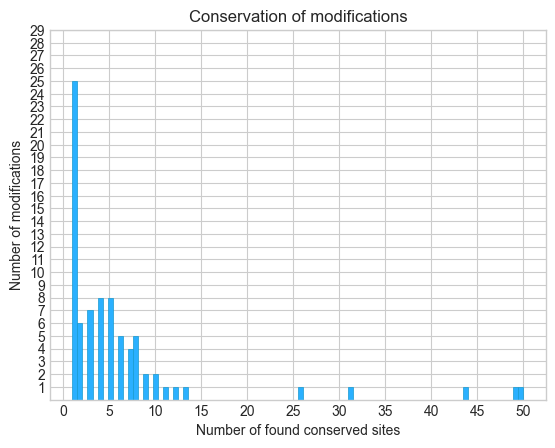

In [10]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.hist(conservedNum, bins=90, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Conservation of modifications', fontsize=12)
plt.xlabel('Number of found conserved sites', fontsize=10)
plt.ylabel('Number of modifications', fontsize=10)
plt.xticks(range(0, 55, 5))
plt.yticks(range(1, 30))
plt.show() 

From these results, it becomes clear that most of the modification sites are only conserved in a few other species. However, for some sites, a very high number of modifications has already been previously reported. This does include the two more in detail discussed benzoate-CoA ligases (Q2LRH0 being Bcl2, Q2RLH7 being Bcl1). 

In more detail, the sites found more than 10 times are:
- Q2LQZ7, position K374 (acetylation): this atpA residue is found to be acetylated in 18 other species, spanning both pro- and eukaryotes (all hits with high coverage, BLAST identity around 50-60%). While no special properties are attributed to this residue in UniProt, it can be noted that this residue is close to a critical residue for activity (363).
- Q2LR33, position 62 (acetylation): this eno residue is found to be acetylated in 8 other species, spanning both pro- and eukaryotes (all hits with high coverage, BLAST identity around 50-60%). No special properties are attributed to this residue in UniProt. While enolase is known to be regulated by acetylation, this particular site does not yet seem to be functionally elucidated in that respect.
- Q2LR69, position 541 (acetylation): while this long-chain-fatty-acid--CoA ligase acetylation gets many FLAMS hits, the BLAST statistics show that most aligned proteins have very low sequence identity (<30%). In general, it seems like many of these hits do bind CoA, which might explain why BLAST matched them. No special properties are attributed to this residue in UniProt, however in one of the hits (Q8VCW8, positon 599, but BLAST identity of 25.99%), this residue is known to bind ATP. Given the low sequence similarity, a more in depth investigation should be warranted, but it might be interesting to further investigate this site.
- Q2LRH0, position 517 (acetylation): this 4-hydroxybenzoate--CoA ligase / benzoate--CoA ligase residue is found to be acetylated in 13 other species, but most hits have very low sequence identity (<30%). Among the best hits, FLAMS reports *Rhodopseudomonas palustris*' badA, for which the effect of this exact matched acetylation has been studied: FLAMS provides the PubMed ID 20345662 for this article. 
- Q2LRH7, position 517 (acetylation): this 4-hydroxybenzoate--CoA ligase / benzoate--CoA ligase residue is found to be acetylated in 13 other species, but most hits have very low sequence identity (<30%). Among the best hits, FLAMS reports *Rhodopseudomonas palustris*' badA, for which the effect of this exact matched acetylation has been studied: FLAMS provides the PubMed ID 20345662 for this article. Most hits are shared with the hits for Q2LRH0.
- Q2LTG3, position 69 (acetylation): this groES residue is found to be acetylated in 10 other species (all groES proteins, with high coverage and BLAST identity around 50-60%). No special properties are attributed to this residue in UniProt. 
- Q2LUN4, position 172 (acetylation): this 3-hydroxyacyl-CoA dehydrogenase residue is found to be acetylated in 6 other species (all CoA binding, mostly hydroxyacyl dehydrogenases, although nearly all hits have very low sequence identities). No special properties are attributed to this residue in UniProt. 
- Q2LVG3, position 60 (acetylation): this thioredoxin is found to be acetylated in 19 other species, spanning both pro- and eukaryotes (the hits represent both low coverage/low identity hits, as well as hits that more likely). No special properties are attributed to this residue in UniProt.

## References

Greiner-Haas,F. *et al.* (2021) Changes of the Proteome and Acetylome during Transition into the Stationary Phase in the Organohalide-Respiring Dehalococcoides mccartyi Strain CBDB1. *Microorganisms*, **9**, 365.

Muroski,J.M. *et al.* (2022) The Acyl-Proteome of Syntrophus aciditrophicus Reveals Metabolic Relationships in Benzoate Degradation. *Mol. Cell. Proteomics*, **21**.

Weinert,B.T. *et al.* (2013) Lysine Succinylation Is a Frequently Occurring Modification in Prokaryotes and Eukaryotes and Extensively Overlaps with Acetylation. *Cell Rep.*, **4**, 842–851.

Xu,J.-Y. *et al.* (2020) Dynamic Characterization of Protein and Posttranslational Modification Levels in Mycobacterial Cholesterol Catabolism. *mSystems*, **5**, e00424-19.